# 통신 월별 네트워크 KPI: ARPU와 이탈 선그래프를 결합한 데이터 사용량 막대그래프 (PROC GBARLINE)

## 요약

이 노트북은 **PROC GBARLINE**을 사용하여 월별 모바일 데이터 사용량의 수직 막대그래프에 ARPU, 이탈, 지원 티켓의 선그래프를 겹쳐 그린다 — 통신 분석가가 사용량 증가가 실제로 매출과 고객유지로 이어지는지 살펴보기 위해 만드는 전형적인 "이중축" KPI 대시보드다. 가입자별 레코드를 인라인으로 합성 생성한 다음, 서브그룹·사용자 지정 오른쪽 축·참조 심볼·범례와 함께 BAR 및 LINE 문을 사용한다.

## 데이터 출처

**데이터셋: `telco_kpi`** — 가입자·월별 합성 레코드(4개월 × 요금제 3단계 × 가입자 8명 = 96행), `call streaminit(20260531)`로 인라인 생성. 패널은 96행으로 유지되어 무라이선스 모드의 100개 관측치 제한 안에 여유 있게 들어가며, 모든 월과 요금제 등급이 빠짐없이 채워진다.

| 변수 | 유형 | 설명 |
|----------|------|-------------|
| `month`  | 문자 | 달력 월 레이블 (1월~4월) |
| `plan`   | 문자 | 요금제 등급: 선불, 후불, 패밀리 |
| `data_gb`| 숫자  | 월간 모바일 데이터 사용량(GB, 감마분포를 따르며 완만한 계절 상승과 느린 증가가 있음) |
| `arpu`   | 숫자  | 가입자당 평균 매출(USD, 요금제 등급이 높을수록·월이 지날수록 상승) |
| `churn`  | 숫자  | 월별 이탈 플래그(0/1, 베르누이 분포; 기간 초반과 낮은 등급에서 더 높음) |
| `tickets`| 숫자  | 개설된 지원 티켓 수(포아송 계수) |

# PROC GBARLINE을 이용한 통신 월별 네트워크 KPI

통신사업자는 몇 가지 월별 KPI에 사업의 성패가 달려 있다: 가입자가 소비하는 **데이터**의 양, 그 소비가 만들어내는 **ARPU**(가입자당 평균 매출), 이탈하는 고객 수인 **이탈(churn)**, 그리고 그 배후의 **지원 티켓** 부담이다. 이 지표들은 기가바이트, 달러, 작은 건수처럼 서로 매우 다른 척도에 존재하므로, 이를 하나의 반응축에 그리면 이야기가 가려진다.

`PROC GBARLINE`은 정확히 이를 위해 만들어졌다. 왼쪽 축에 대해 수직 **막대**그래프를 그리고, 독립적인 오른쪽 축에 대해 하나 이상의 **선**그래프를 겹쳐 그린다. 이 노트북에서는 사용량 대 매출 대시보드를 만든 다음, 요금제 수준 서브그룹, 사용자 지정 오른쪽 축, 다중 선 오버레이를 점진적으로 쌓아 올린다.

## 1단계 — 합성 가입자·월별 데이터 생성

아래 DATA 스텝은 현실적인 패널을 만들어낸다: 4개월(1월~4월) × 요금제 3단계(선불, 후불, 패밀리) × 가입자 8명씩, 총 96행이다. 재현성을 위해 `call streaminit`으로 난수생성기 시드를 고정하고, 각 KPI를 해당 분야에 맞는 분포에서 뽑는다:

- **데이터 사용량**은 완만한 계절 상승과 느린 월간 증가를 가진 감마분포에서.
- **ARPU**는 요금제 등급이 높을수록, 월이 지날수록 상승하며 정규 잡음이 섞인다.
- **이탈**은 기간 초반과 저가 등급에서 더 높은 베르누이 플래그로.
- **지원 티켓**은 초반에 약간 더 많은 포아송 계수로.

외부 파일은 읽지 않는다 — 모든 것이 자기완결적이며, 96행 패널은 무라이선스 100개 관측치 상한 안에 머물러 모든 월과 등급이 빠짐없이 렌더링된다.

In [1]:
데이터 telco_kpi;
    호출 streaminit(20260531);
    길이 month $6 plan $12;
    반복 mi = 1 까지 4;
        만약 mi=1 이면 month="1월";
        아니면 만약 mi=2 이면 month="2월";
        아니면 만약 mi=3 이면 month="3월";
        아니면 month="4월";
        /* 완만한 계절 상승과 느린 데이터 증가 */
        season = 1 + 0.10*sin((mi-1)/12*2*3.14159);
        반복 plan_i = 1 까지 3;
            만약 plan_i = 1 이면 plan = "선불";
            아니면 만약 plan_i = 2 이면 plan = "후불";
            아니면 plan = "패밀리";
            반복 rep = 1 까지 8;
                /* 월간 모바일 데이터 사용량 (GB) */
                data_gb = rand('gamma', 4) * 3 * season
                          + (mi * 0.4);
                /* 가입자당 평균 매출 ($) */
                arpu = 28 + 6*plan_i + rand('normal', 0, 4)
                       + mi*0.3;
                /* 월별 이탈 플래그, 연초에 더 높음 */
                churn = rand('bernoulli',
                             0.18 - 0.03*plan_i + 0.02*(4-mi));
                /* 개설된 지원 티켓 */
                tickets = rand('poisson', 1.6 + 0.15*(4-mi));
                출력;
            종료;
        종료;
    종료;
    제거 mi plan_i rep season;
실행;


NOTE: DATA telco_kpi


NOTE: Wrote telco_kpi (96 rows, 6 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds


## 2단계 — 핵심 대시보드: 사용량 막대 + ARPU 선

이것이 전형적인 `GBARLINE` 패턴이다. `BAR` 문은 월평균 데이터 사용량(`SUMVAR=data_gb TYPE=mean`)을 그리고, 단일 `LINE` 문이 오른쪽 축에 평균 ARPU를 겹쳐 그린다(`STAT=mean TYPE=join`). ODS 그래픽을 켜고 차트에 두 줄짜리 제목을 부여한다. `COUTLINE=`과 `WIDTH=`가 막대를 다듬어 준다.

                                                  월별 모바일 데이터 사용량과 ARPU                                                  
                                                   가상 통신 네트워크 KPI 데이터                                                   




NOTE: ODS Graphics is ON (width=640px, height=480px, format=SVG).
NOTE: Option TITLE changed to 월별 모바일 데이터 사용량과 ARPU.
NOTE: Option TITLE2 changed to 가상 통신 네트워크 KPI 데이터.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


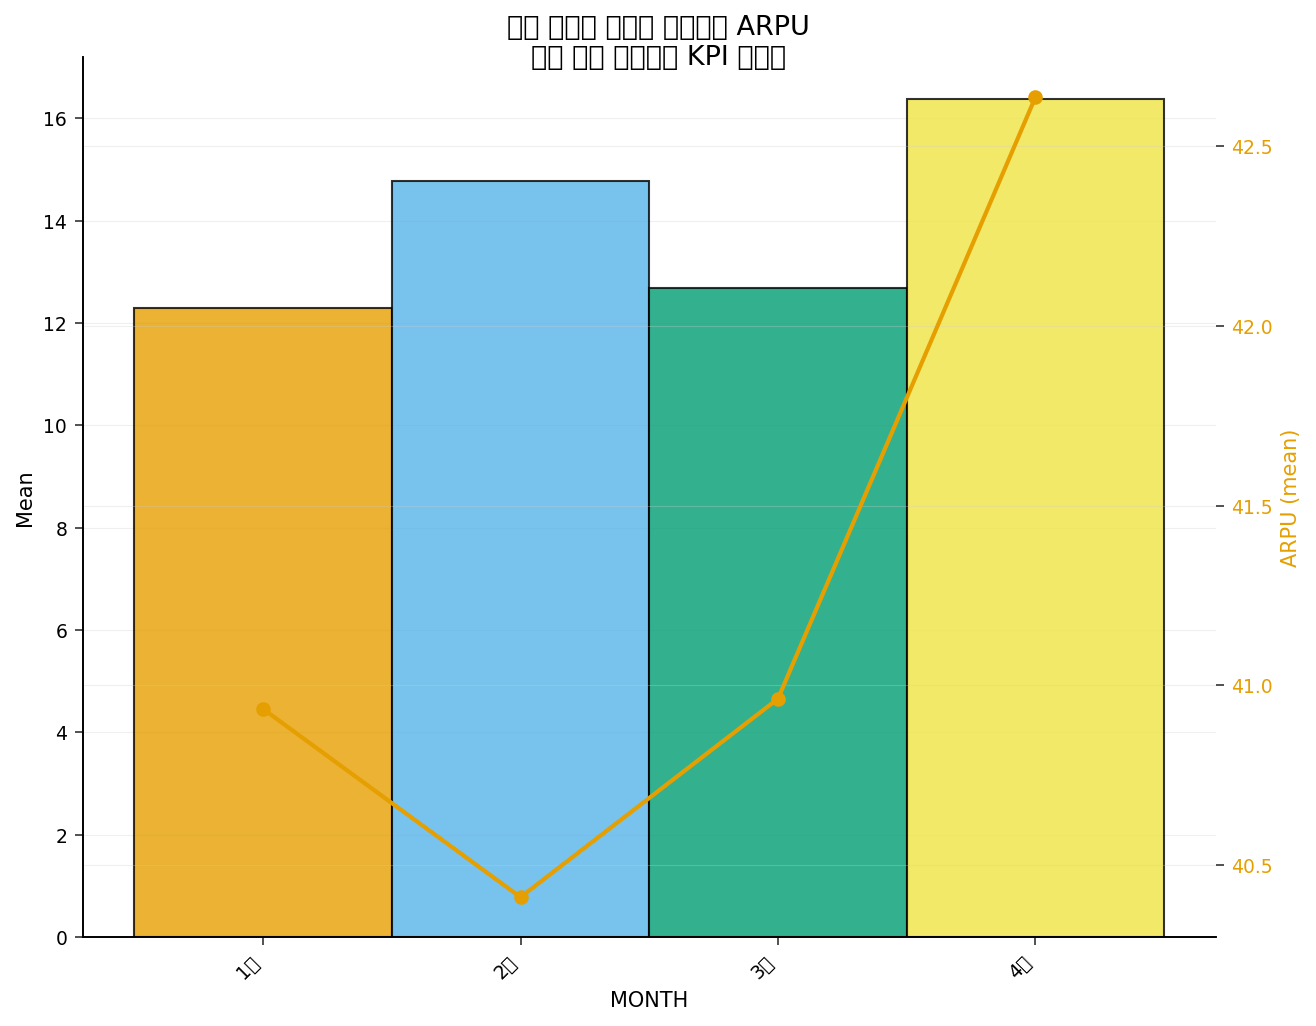

In [2]:
ODS GRAPHICS ON;
제목 "월별 모바일 데이터 사용량과 ARPU";
title2 "가상 통신 네트워크 KPI 데이터";

처리 gbarline 데이터=telco_kpi;
    bar month / SUMVAR=data_gb type=mean
                coutline=black WIDTH=6;
    line arpu / STAT=mean type=JOIN;
    라벨 month="월" data_gb="데이터 사용량(GB)" arpu="평균 ARPU($)";
실행;

## 3단계 — 요금제별로 사용량 분해, 이탈 겹쳐 그리기

`TYPE=mean`을 `TYPE=sum`으로 바꾸고 `SUBGROUP=plan`을 추가하면 매월 막대가 요금제 등급별로 누적되어 어느 세그먼트가 전체 물량을 이끄는지 볼 수 있다. 겹쳐 그린 `LINE`은 이제 이탈 이벤트의 월별 **건수**를 니들 플롯(`STAT=sum TYPE=needle`)으로 그려, 매끄러운 추세선이 아니라 이산적인 사건 건수로 자연스럽게 읽히는 수직 스파이크를 보여준다.

                                                  요금제별 데이터 사용량과 월별 이탈                                                   
                                                   가상 통신 네트워크 KPI 데이터                                                   




NOTE: Option TITLE changed to 요금제별 데이터 사용량과 월별 이탈.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


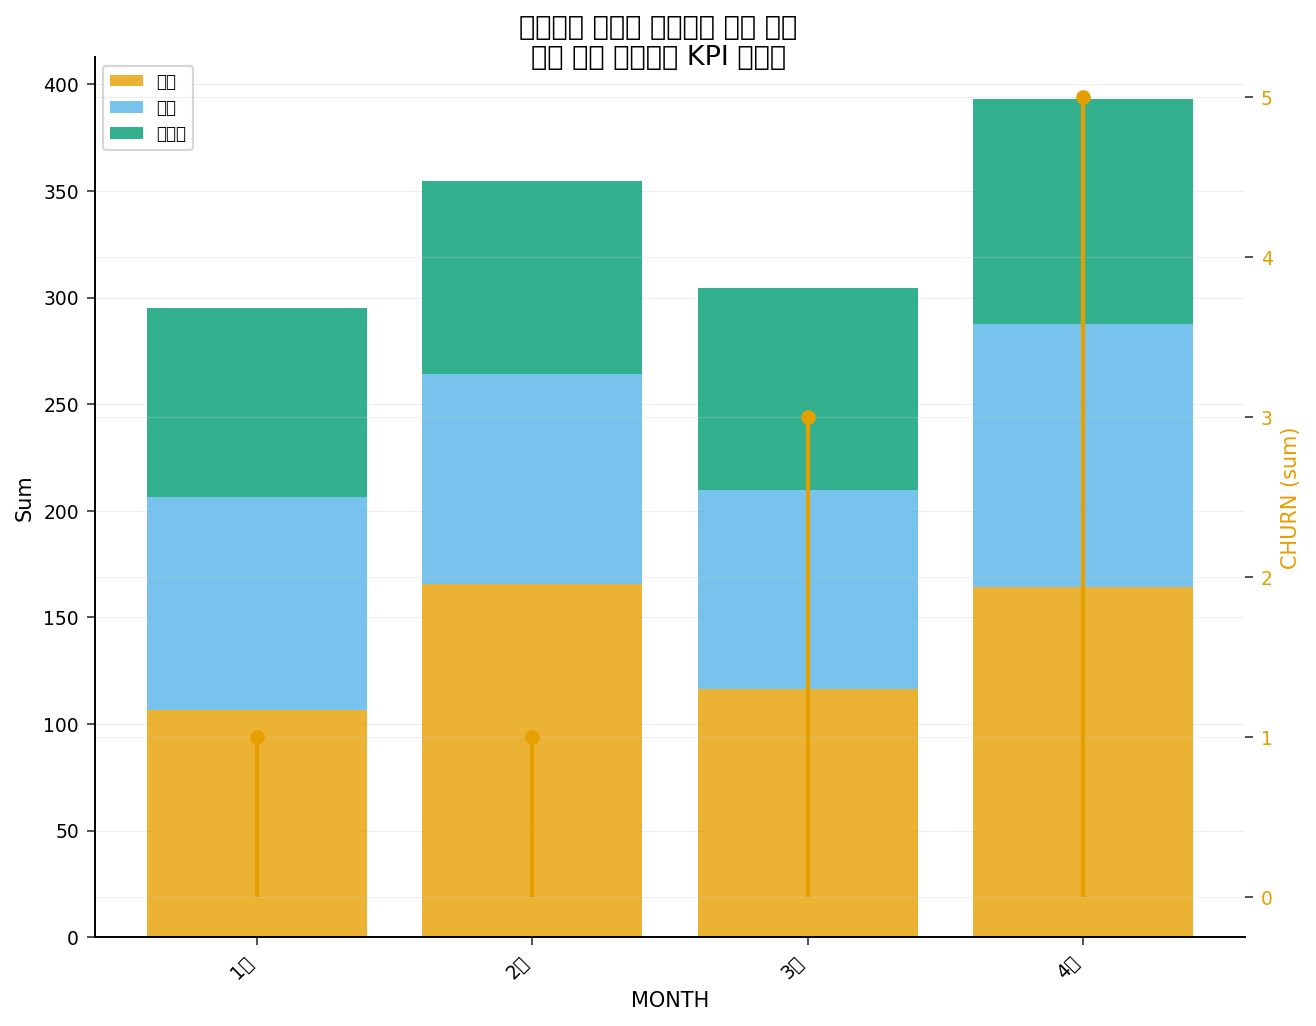

In [3]:
제목 "요금제별 데이터 사용량과 월별 이탈";

처리 gbarline 데이터=telco_kpi;
    bar month / SUMVAR=data_gb type=sum SUBGROUP=plan;
    line churn / STAT=sum type=needle;
    라벨 month="월" data_gb="데이터 사용량(GB)" plan="요금제" churn="이탈 건수";
실행;

## 4단계 — 오른쪽 축과 선 마커 제어

발표용 차트를 위해 `AXIS` 정의로 플롯의 (오른쪽) 축을 고정 범위에 고정하고 레이블을 붙인 다음, `RAXIS=axis2`로 선에 연결한다. `SYMBOL` 정의는 ARPU 선에 빨간 점선 마커를 부여한다. 또한 `OUTSIDE=sum`으로 각 막대 위에 막대 합계를 표시한다.

                                                 총 사용량(막대) 대 평균 ARPU(선)                                                 
                                                   가상 통신 네트워크 KPI 데이터                                                   




NOTE: Option TITLE changed to 총 사용량(막대) 대 평균 ARPU(선).
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json


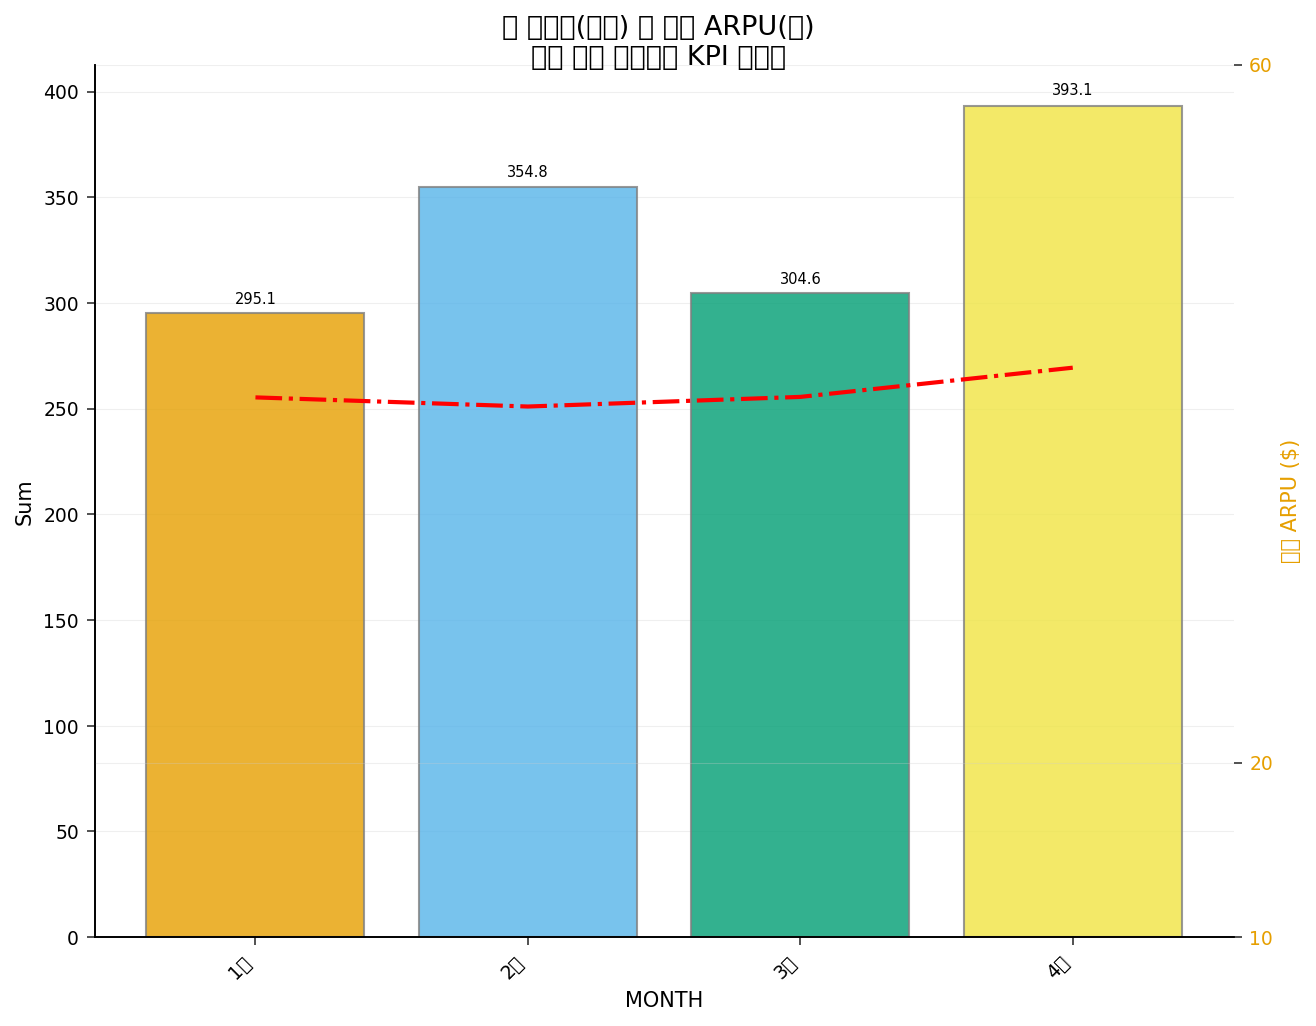

In [4]:
제목 "총 사용량(막대) 대 평균 ARPU(선)";

처리 gbarline 데이터=telco_kpi;
    axis2 ORDER=(20 까지 60 기준 10) 라벨=("평균 ARPU ($)");
    symbol1 color=red INTERPOL=JOIN VALUE=dot HEIGHT=1.4;
    bar month / SUMVAR=data_gb type=sum
                outside=sum coutline=gray;
    line arpu / STAT=mean type=JOIN raxis=axis2 SYMBOL=symbol1;
    라벨 month="월" data_gb="데이터 사용량(GB)" arpu="평균 ARPU($)";
실행;

## 5단계 — 사용자 지정 범례를 갖춘 다중 선 오버레이

`GBARLINE`은 두 개 이상의 `LINE` 문을 허용하므로, 사용량 막대에 대해 두 가지 운영 신호 — 평균 지원 티켓(`type=join`)과 총 이탈(`type=needle`) — 을 동시에 비교할 수 있다. 하단에 배치된 `LEGEND` 정의가 요금제 서브그룹을 설명해 준다.

                                                      지원 티켓과 이탈 추세                                                      
                                                   가상 통신 네트워크 KPI 데이터                                                   




NOTE: Option TITLE changed to 지원 티켓과 이탈 추세.
NOTE: PROC GBARLINE data=telco_kpi

NOTE: ODS plot written: gbarline.spec.json
NOTE: ODS Graphics is OFF.


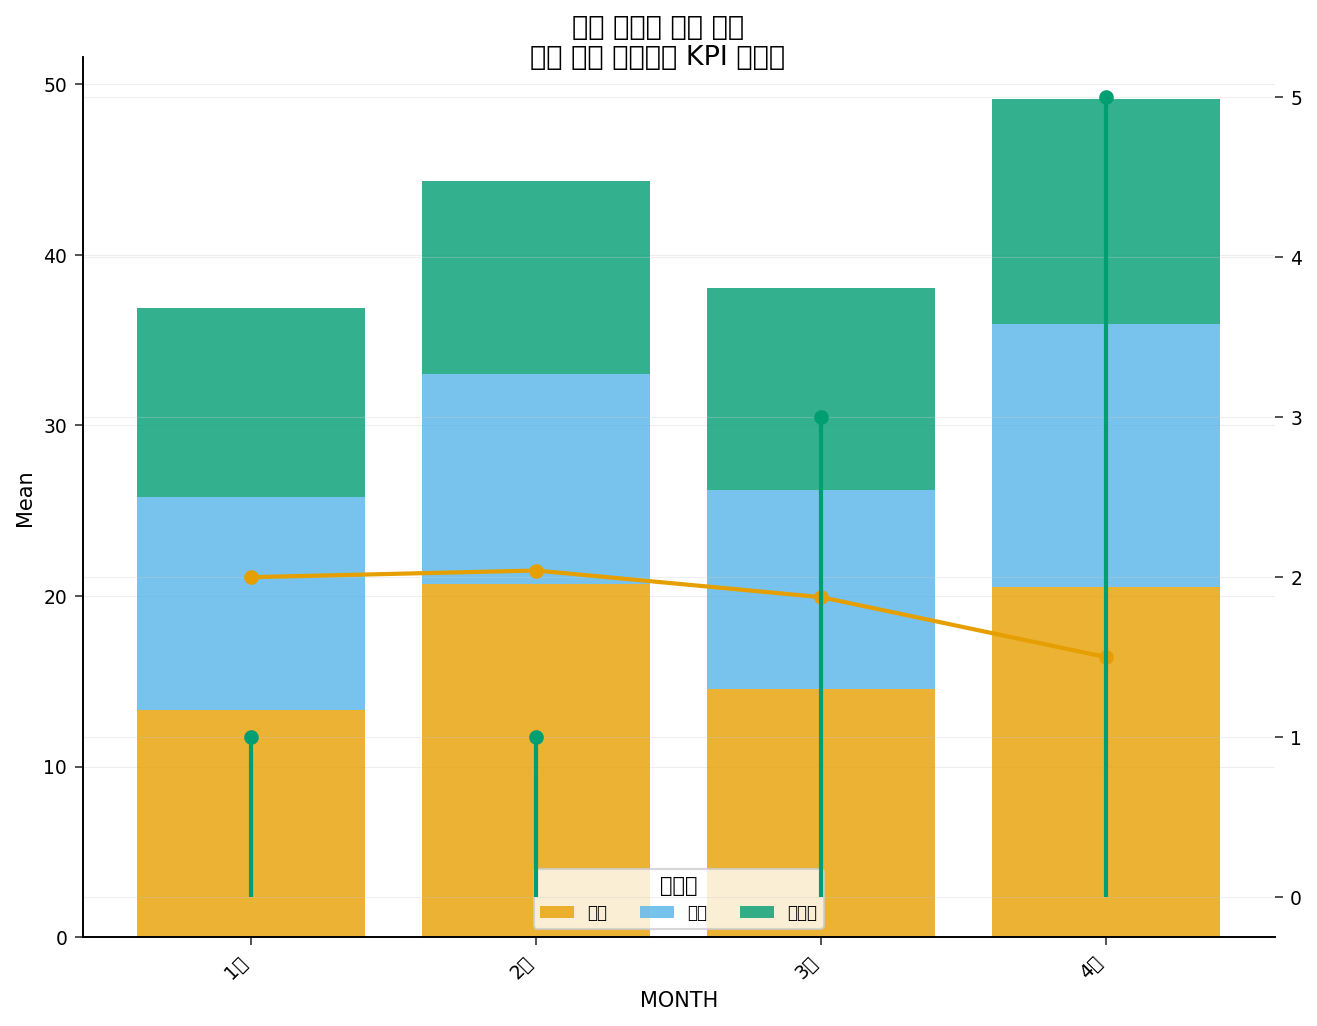

In [5]:
제목 "지원 티켓과 이탈 추세";

처리 gbarline 데이터=telco_kpi;
    legend1 라벨=("요금제") position=(bottom) ACROSS=3;
    bar month / SUMVAR=data_gb type=mean SUBGROUP=plan
                legend=legend1;
    line tickets / STAT=mean type=JOIN;
    line churn / STAT=sum type=needle;
    라벨 month="월" data_gb="데이터 사용량(GB)" plan="요금제" tickets="지원 티켓 수" churn="이탈 건수";
실행;

ODS GRAPHICS OFF;

## 결과 해석

1월~4월 구간에서 대시보드는 일관된 통신업 이야기를 들려준다. **데이터 사용량**(막대)은 월별로 들쭉날쭉하지만 상승 추세를 보이며 **4월**에 정점을 찍는다 — 평균 사용량은 1월 약 12.3GB에서 4월 16.4GB로 오르고(2단계), 총 물량은 295GB에서 393GB로 증가한다(4단계의 `OUTSIDE=sum` 레이블). **ARPU 선**은 2월에 살짝 내려갔다가 4월 자체 최고치인 약 \$42.6까지 오르는데, 이는 사업자가 늘어난 소비를 그냥 흘려보내지 않고 점점 더 수익화하고 있음을 뜻한다 — 4단계의 오른쪽 축은 이 움직임을 읽기 쉽도록 \$20~\$60로 고정되어 있다.

요금제별로 누적한 뷰(3단계와 5단계)는 선불 비중이 큰 사업자를 특징짓는 세그먼트 간 긴장을 드러낸다. **선불**(주황색 구간)이 4개월 전체에서 가장 많은 기가바이트를 차지한다 — 대략 553GB로, 후불의 415GB, 패밀리의 380GB보다 많다 — 그럼에도 가입자당 평균 매출은 **가장 낮다**(약 \$36로, 후불 \$41, 패밀리 \$47보다 낮음). **이탈 니들**은 고객유지 위험이 어디에 있는지 확인해 준다: 이탈 이벤트는 선불과 후불 등급에 몰려 있고(구간 전체에서 각각 4건) 패밀리에서는 더 적으며(2건), 가입자 기반과 사용량이 늘어나는 4월을 향해 갈수록 증가한다.

5단계는 이 위에 운영 부담을 겹쳐 보여준다: 평균 **지원 티켓**은 기간 초반에 조금 더 무거웠다가 4월에 접어들며 줄어드는 반면, 이탈 니들은 더 늦게 정점을 찍는다 — 고객유지팀이 주시할 만한 신호다. 운영 관점에서 보면, 데이터 물량에서 가장 빠르게 늘어나는 몫을 소비하면서도 매출은 가장 적고 이탈은 가장 많은 **선불** 가입자에게 고객유지 예산을 집중해야 한다는 결론이 나온다.

`PROC GBARLINE`이 여기서 적합한 도구인 이유는 정확히, 기가바이트 척도의 막대와 달러/건수 척도의 선을 독립된 축에 유지하면서도 월별 시간축은 공유하게 해 주어, 각 KPI를 자신의 척도대로 읽으면서도 함께 볼 수 있게 해주기 때문이다.